In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import make_circles

x,y=make_circles(1000,noise=0.03)

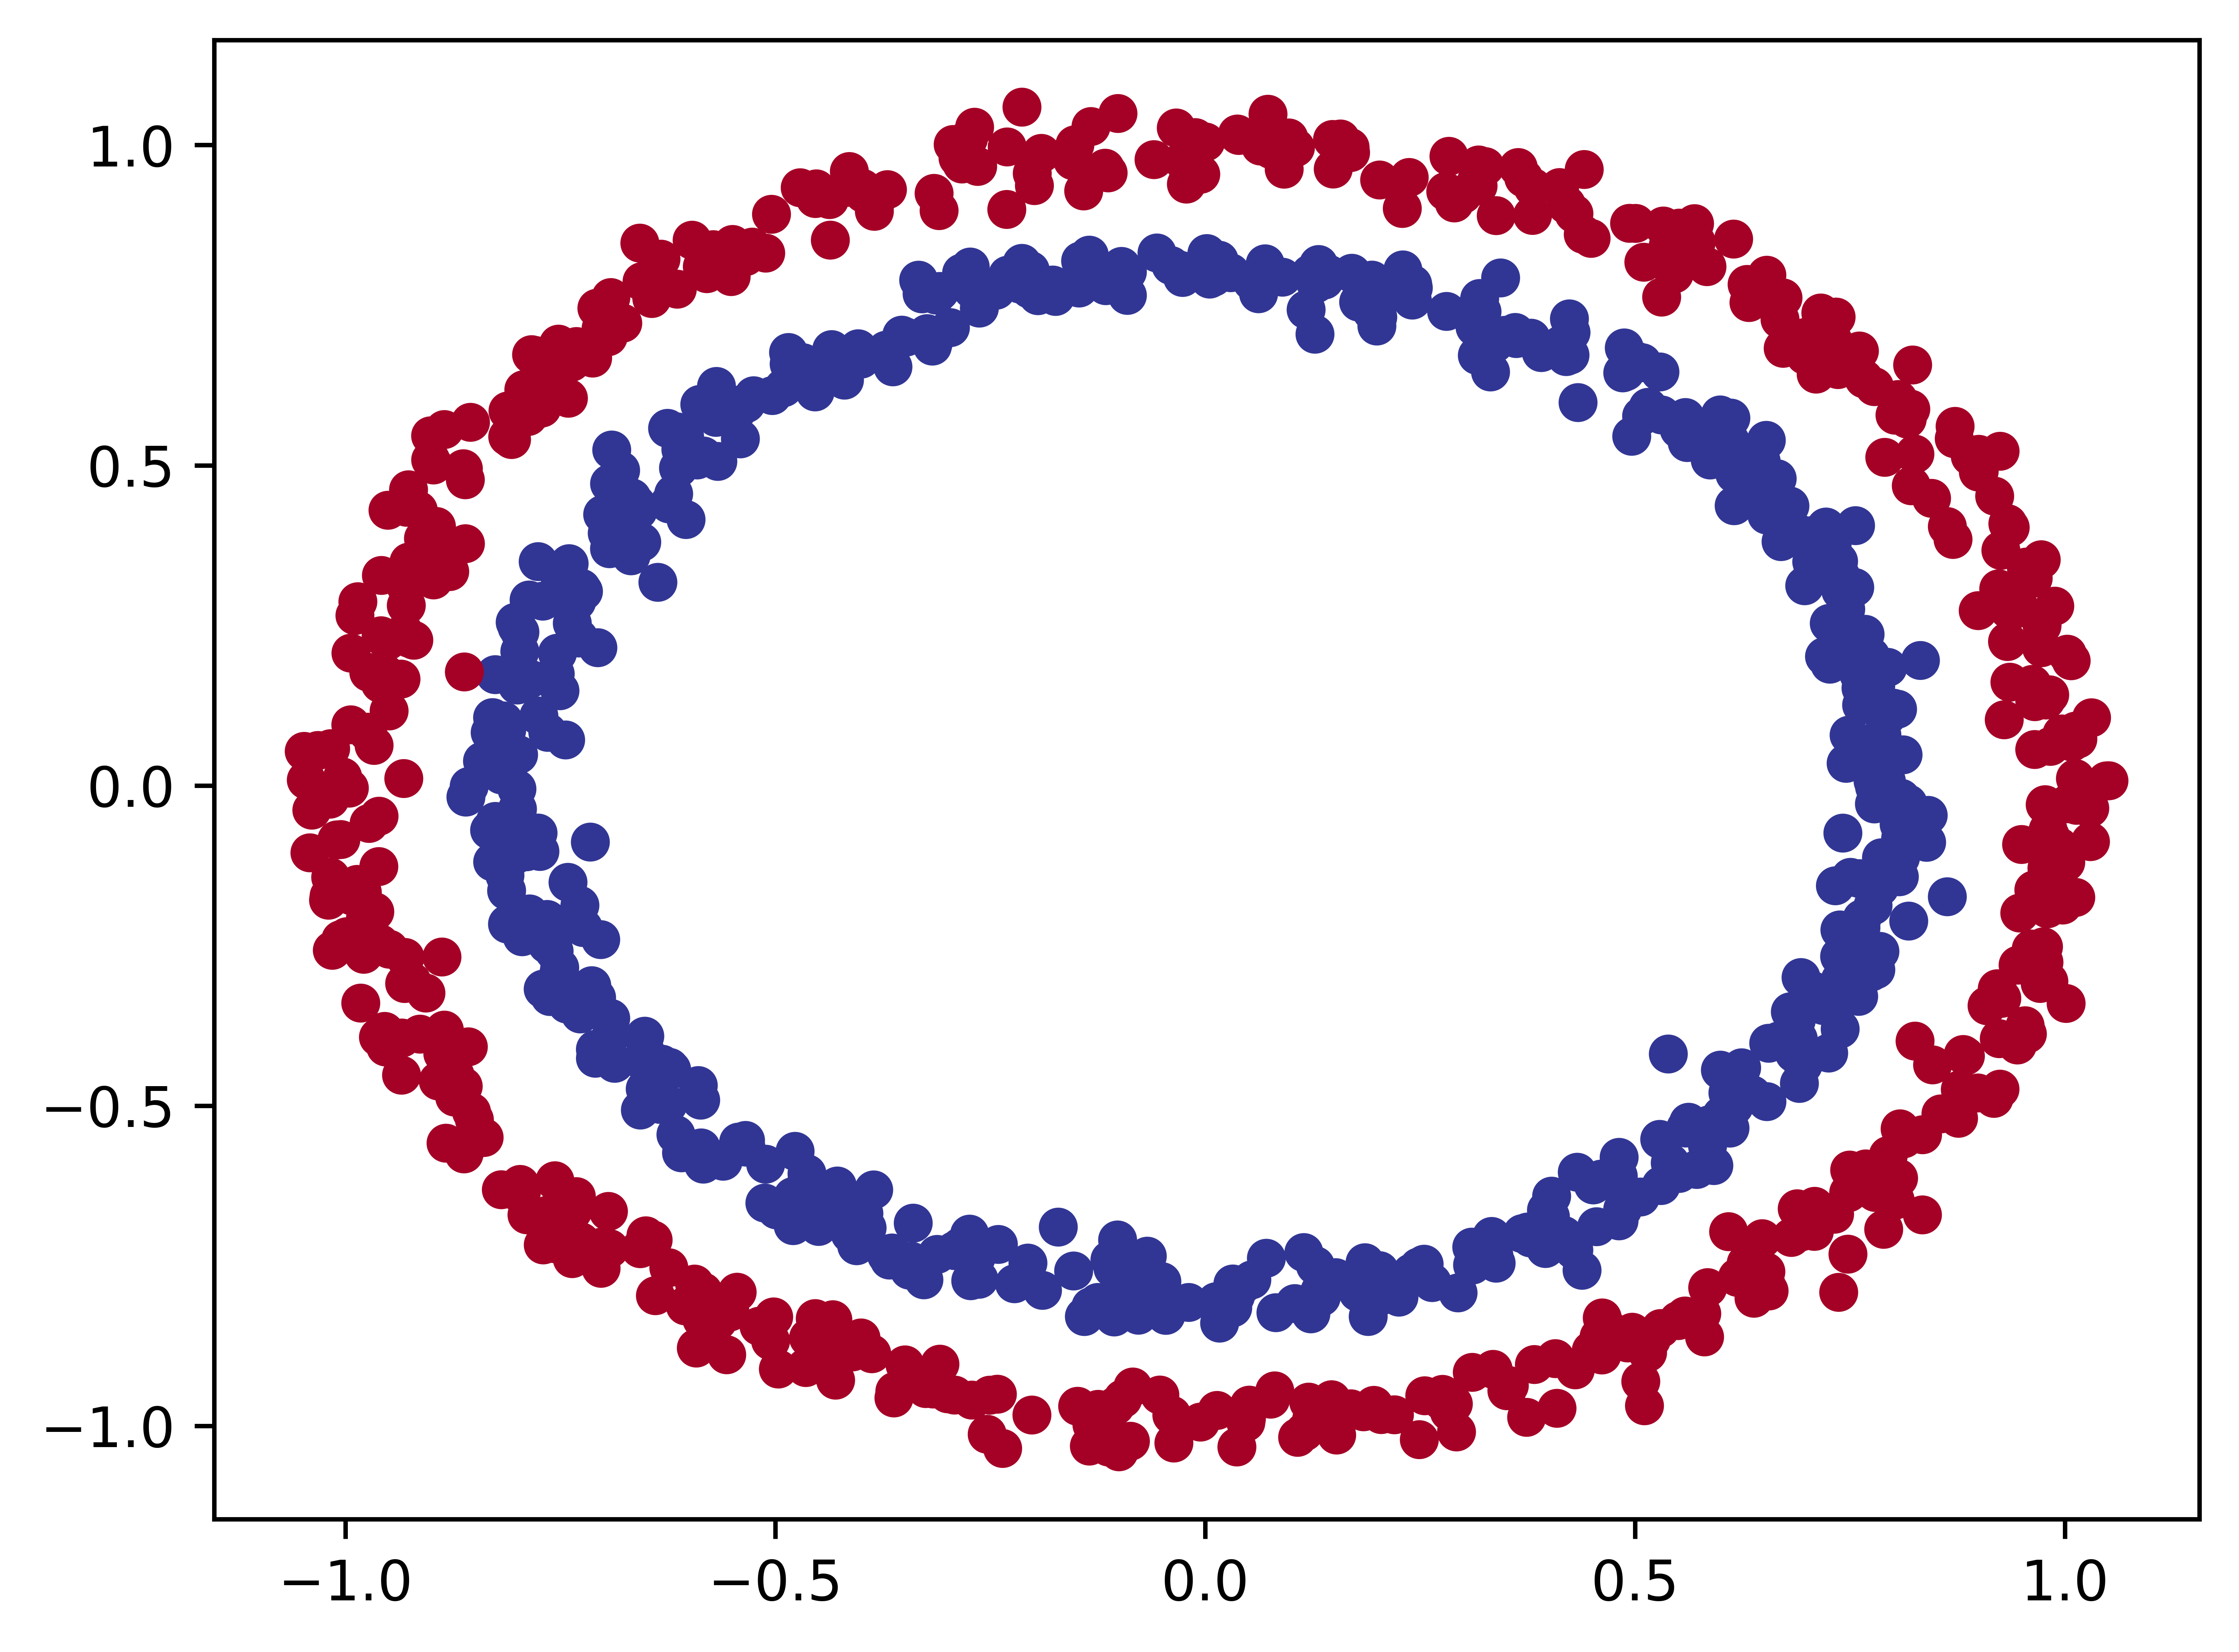

In [3]:
x,y
plt.figure(dpi=1000)
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdYlBu)

In [4]:
x=torch.from_numpy(x).type(torch.float32)

y=torch.from_numpy(y).type(torch.float32)

In [5]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [6]:
## we have the nonlinear weighted and other


## 6.2 building a model with non - linearity

* build a model with non-linear functions

In [7]:
## we can word in 100'rd of dimentions

In [8]:
model=nn.Sequential(
    nn.Linear(in_features=2,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=1)
).to('mps')
    
        

In [9]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)


In [10]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2893,  0.5137],
                      [-0.3987,  0.5940],
                      [-0.5429, -0.1525],
                      [-0.3231, -0.4563],
                      [ 0.6774,  0.2499],
                      [-0.4636,  0.3114],
                      [ 0.6489, -0.3828],
                      [-0.6253, -0.3994],
                      [-0.3509,  0.1490],
                      [ 0.2013,  0.0290]], device='mps:0')),
             ('0.bias',
              tensor([-0.0587,  0.3630,  0.0782,  0.3841, -0.0264,  0.2654, -0.6732,  0.5065,
                       0.1205,  0.3465], device='mps:0')),
             ('2.weight',
              tensor([[ 0.2604, -0.1660, -0.1584, -0.2683, -0.2646,  0.1791, -0.0342,  0.1248,
                        0.2173,  0.1143],
                      [ 0.1674, -0.2479,  0.0966,  0.1645,  0.2225,  0.1014,  0.2638, -0.1514,
                       -0.2983, -0.1597],
                      [ 0.0528,  0.2467, -0.1365, -0.0475,

In [11]:
loss_fn=nn.BCEWithLogitsLoss()

In [12]:
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.1)
x_train=x_train.to('mps')
x_test=x_test.to('mps')
y_train=y_train.to('mps')
y_test=y_test.to('mps')

In [13]:
## 6.3 training a model with non linearity

In [14]:
x_train

tensor([[ 0.3689, -0.6997],
        [ 0.6469,  0.4614],
        [ 0.7743,  0.2018],
        ...,
        [ 0.3175,  0.9361],
        [-0.5897, -0.4685],
        [-0.4130, -0.6999]], device='mps:0')

In [15]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)


In [16]:
# random seed
torch.manual_seed(42)

# put all the data on targer device
x_train=x_train.to('mps')
y_train=y_train.to('mps')
x_test=x_test.to('mps')
y_test=y_test.to('mps')
print(x_train)


tensor([[ 0.3689, -0.6997],
        [ 0.6469,  0.4614],
        [ 0.7743,  0.2018],
        ...,
        [ 0.3175,  0.9361],
        [-0.5897, -0.4685],
        [-0.4130, -0.6999]], device='mps:0')


In [17]:
def accuracy(y_pred,y_train):
    correct=torch.eq(y_pred,y_train).sum().item()
    acc=correct/len(y_pred)

    return acc

In [18]:
epochs=3000
a=[]
l=[]
for epoch in range(epochs):
    model.train()
    y_log=model(x_train)
    loss=loss_fn(y_log.squeeze(),y_train)
    l.append(loss.to('cpu').detach().numpy())
    y_p=torch.round(torch.sigmoid(y_log))
    a.append(accuracy(y_p.squeeze(),y_train))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(loss)

tensor(0.6937, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6934, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6931, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6928, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6926, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6923, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6921, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6919, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6917, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6916, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6914, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6913, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6911, device='mps:0', grad_fn=<

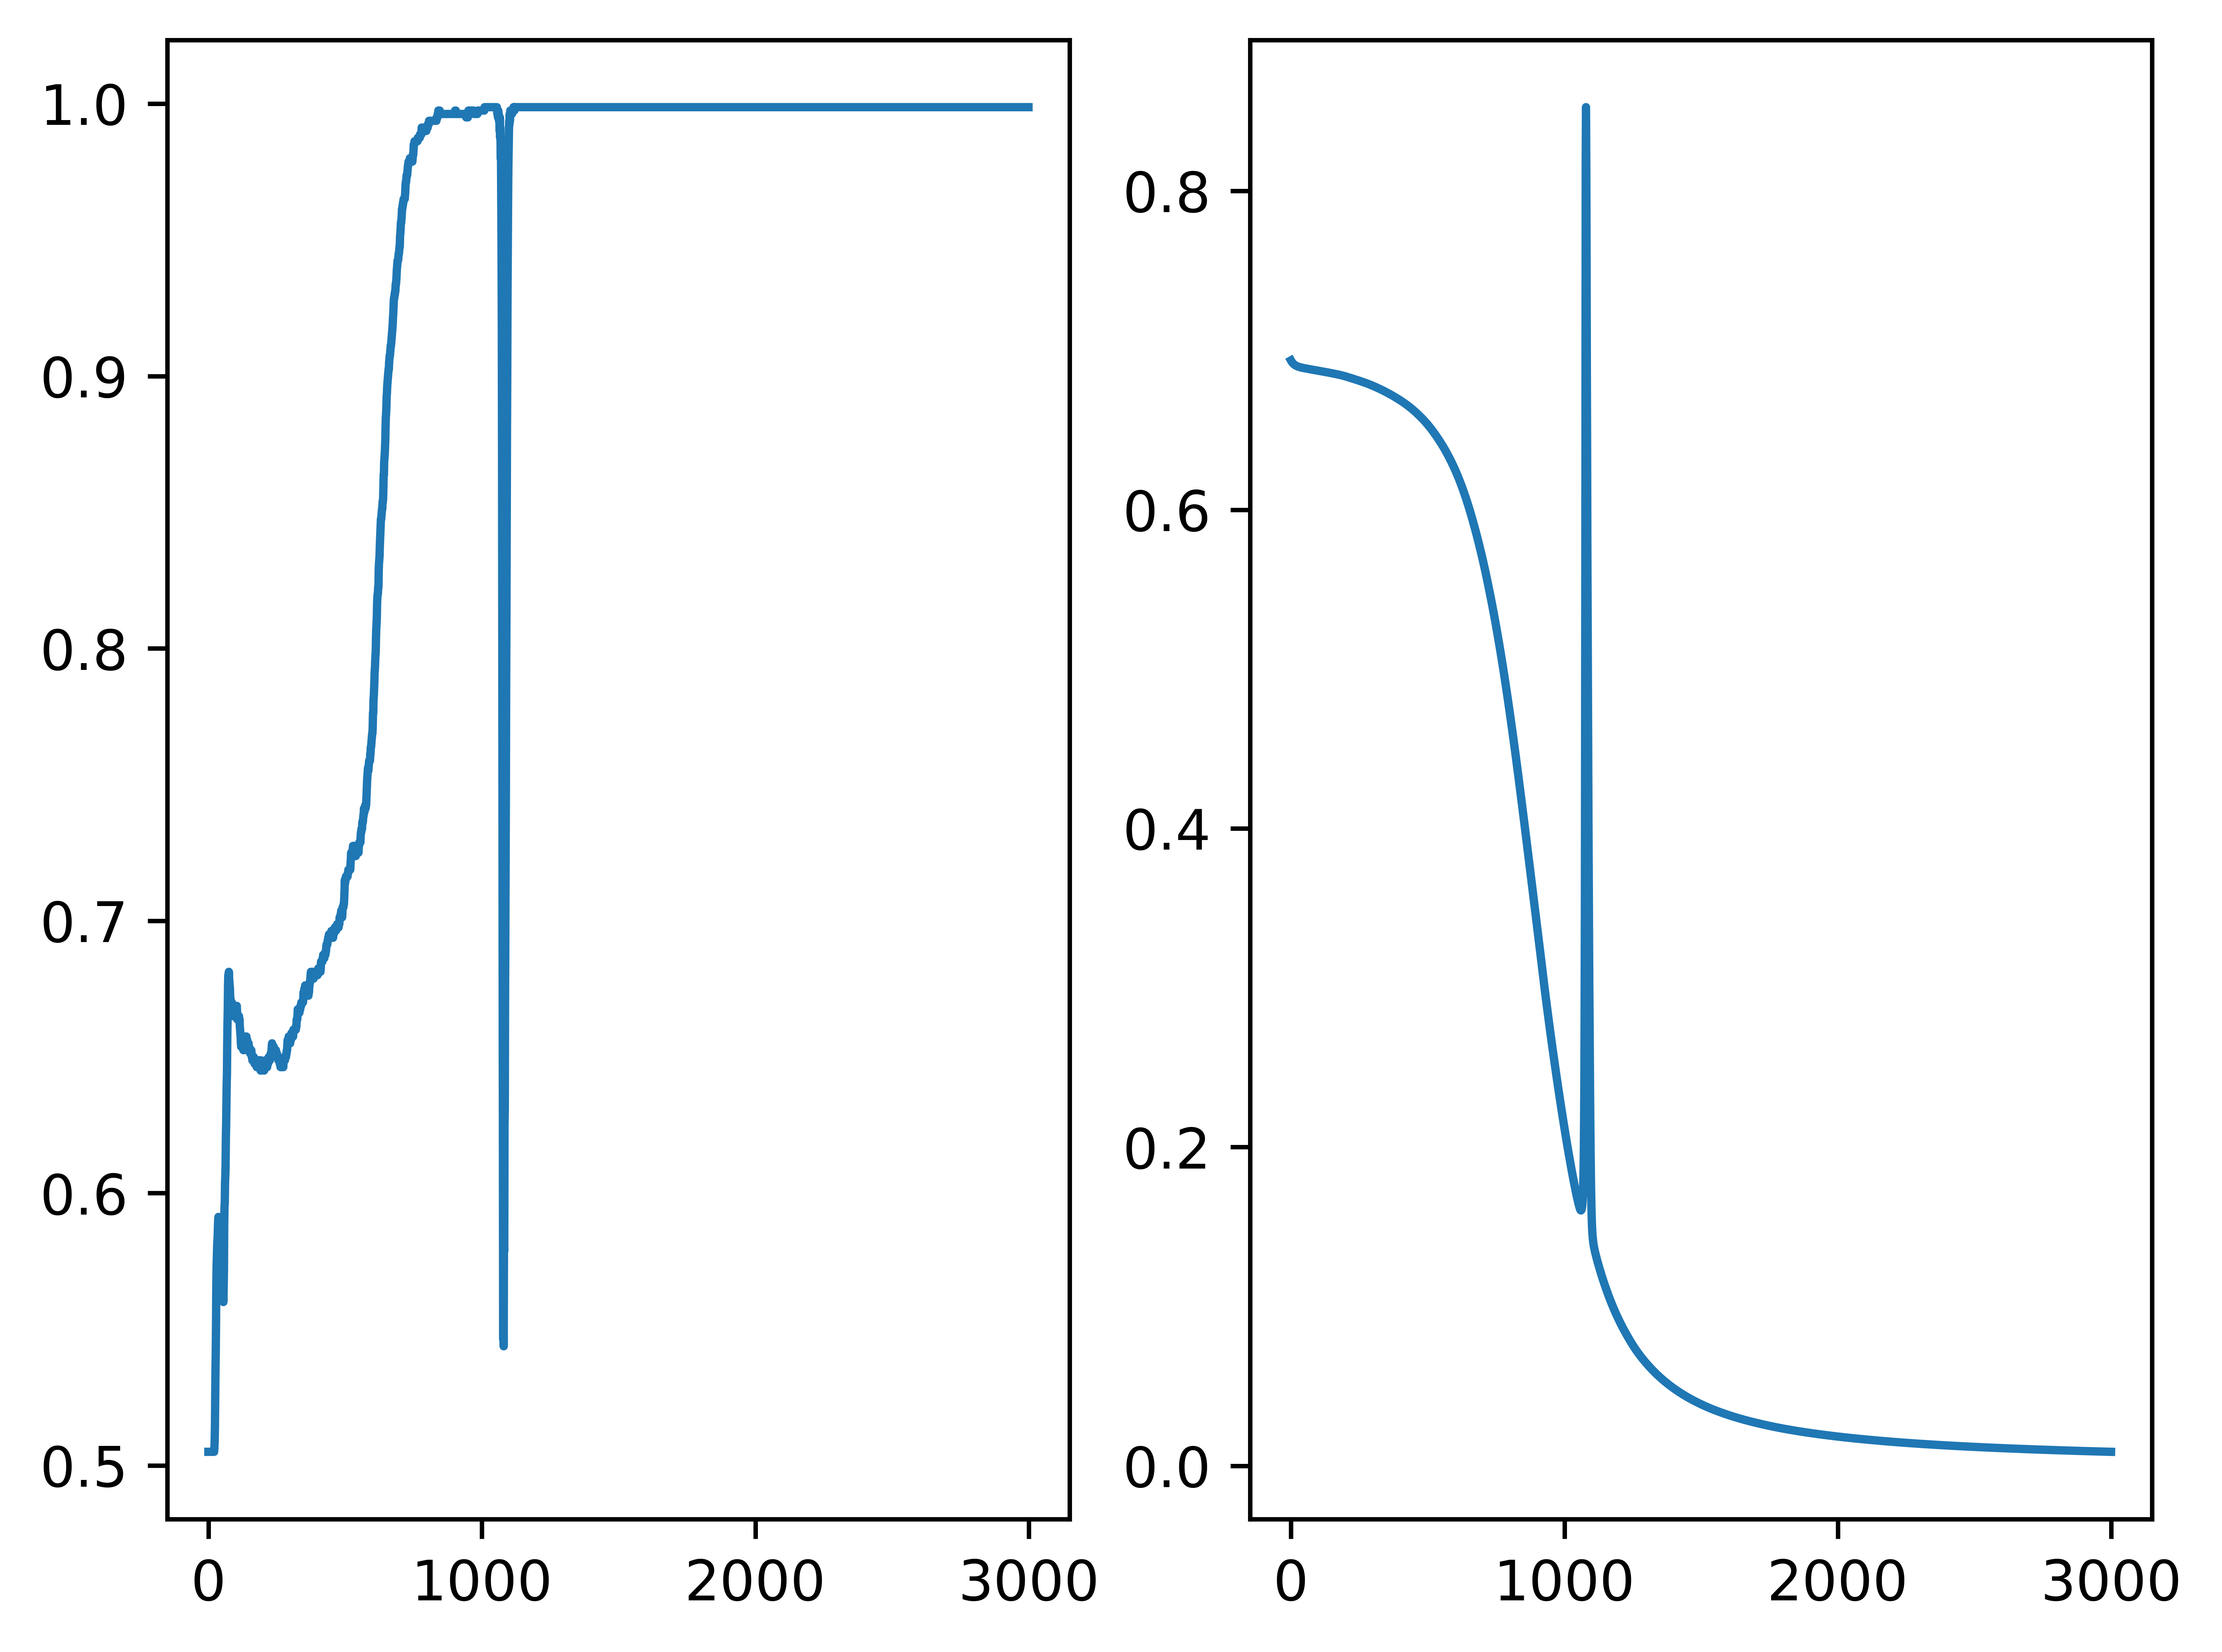

In [19]:
plt.figure(dpi=1000)
plt.subplot(1,2,1)
plt.plot(a)
plt.subplot(1,2,2)
plt.plot(l)

In [20]:
## device agnostic code is the code used to convert the variables from cpu to the mps

model.state_dict()

In [21]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4233,  1.9491],
                      [-2.0113,  2.2287],
                      [-2.5232, -0.4630],
                      [-0.4592, -2.8111],
                      [ 2.7097,  0.4884],
                      [-0.4296,  0.6183],
                      [ 0.6019, -0.3602],
                      [-0.6876, -0.2523],
                      [-0.1959,  0.4342],
                      [ 0.8755,  0.0791]], device='mps:0')),
             ('0.bias',
              tensor([-0.7288, -0.1516, -0.9191, -0.3143, -0.6717,  1.4002, -0.7254,  1.6640,
                       0.8463,  0.2288], device='mps:0')),
             ('2.weight',
              tensor([[ 0.0758, -0.3702, -0.3830, -0.4998, -0.4213,  0.3946, -0.0327,  0.3531,
                        0.3570,  0.0356],
                      [ 0.1674, -0.2479,  0.0966,  0.1645,  0.2225,  0.1014,  0.2638, -0.1514,
                       -0.2983, -0.1597],
                      [ 0.7558,  1.1380,  0.4190,  0.0487,

* mode parameters mode compute power and thats the tradeof

In [26]:
with torch.inference_mode():
    test_logits=model(x_test)
    test_preds=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits.squeeze(),y_test)
print(test_preds)

tensor([[1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
      

In [24]:
test_logits.shape

torch.Size([200, 1])

In [31]:
print(test_loss)
x_test.shape

tensor(0.0112, device='mps:0')


torch.Size([200, 2])

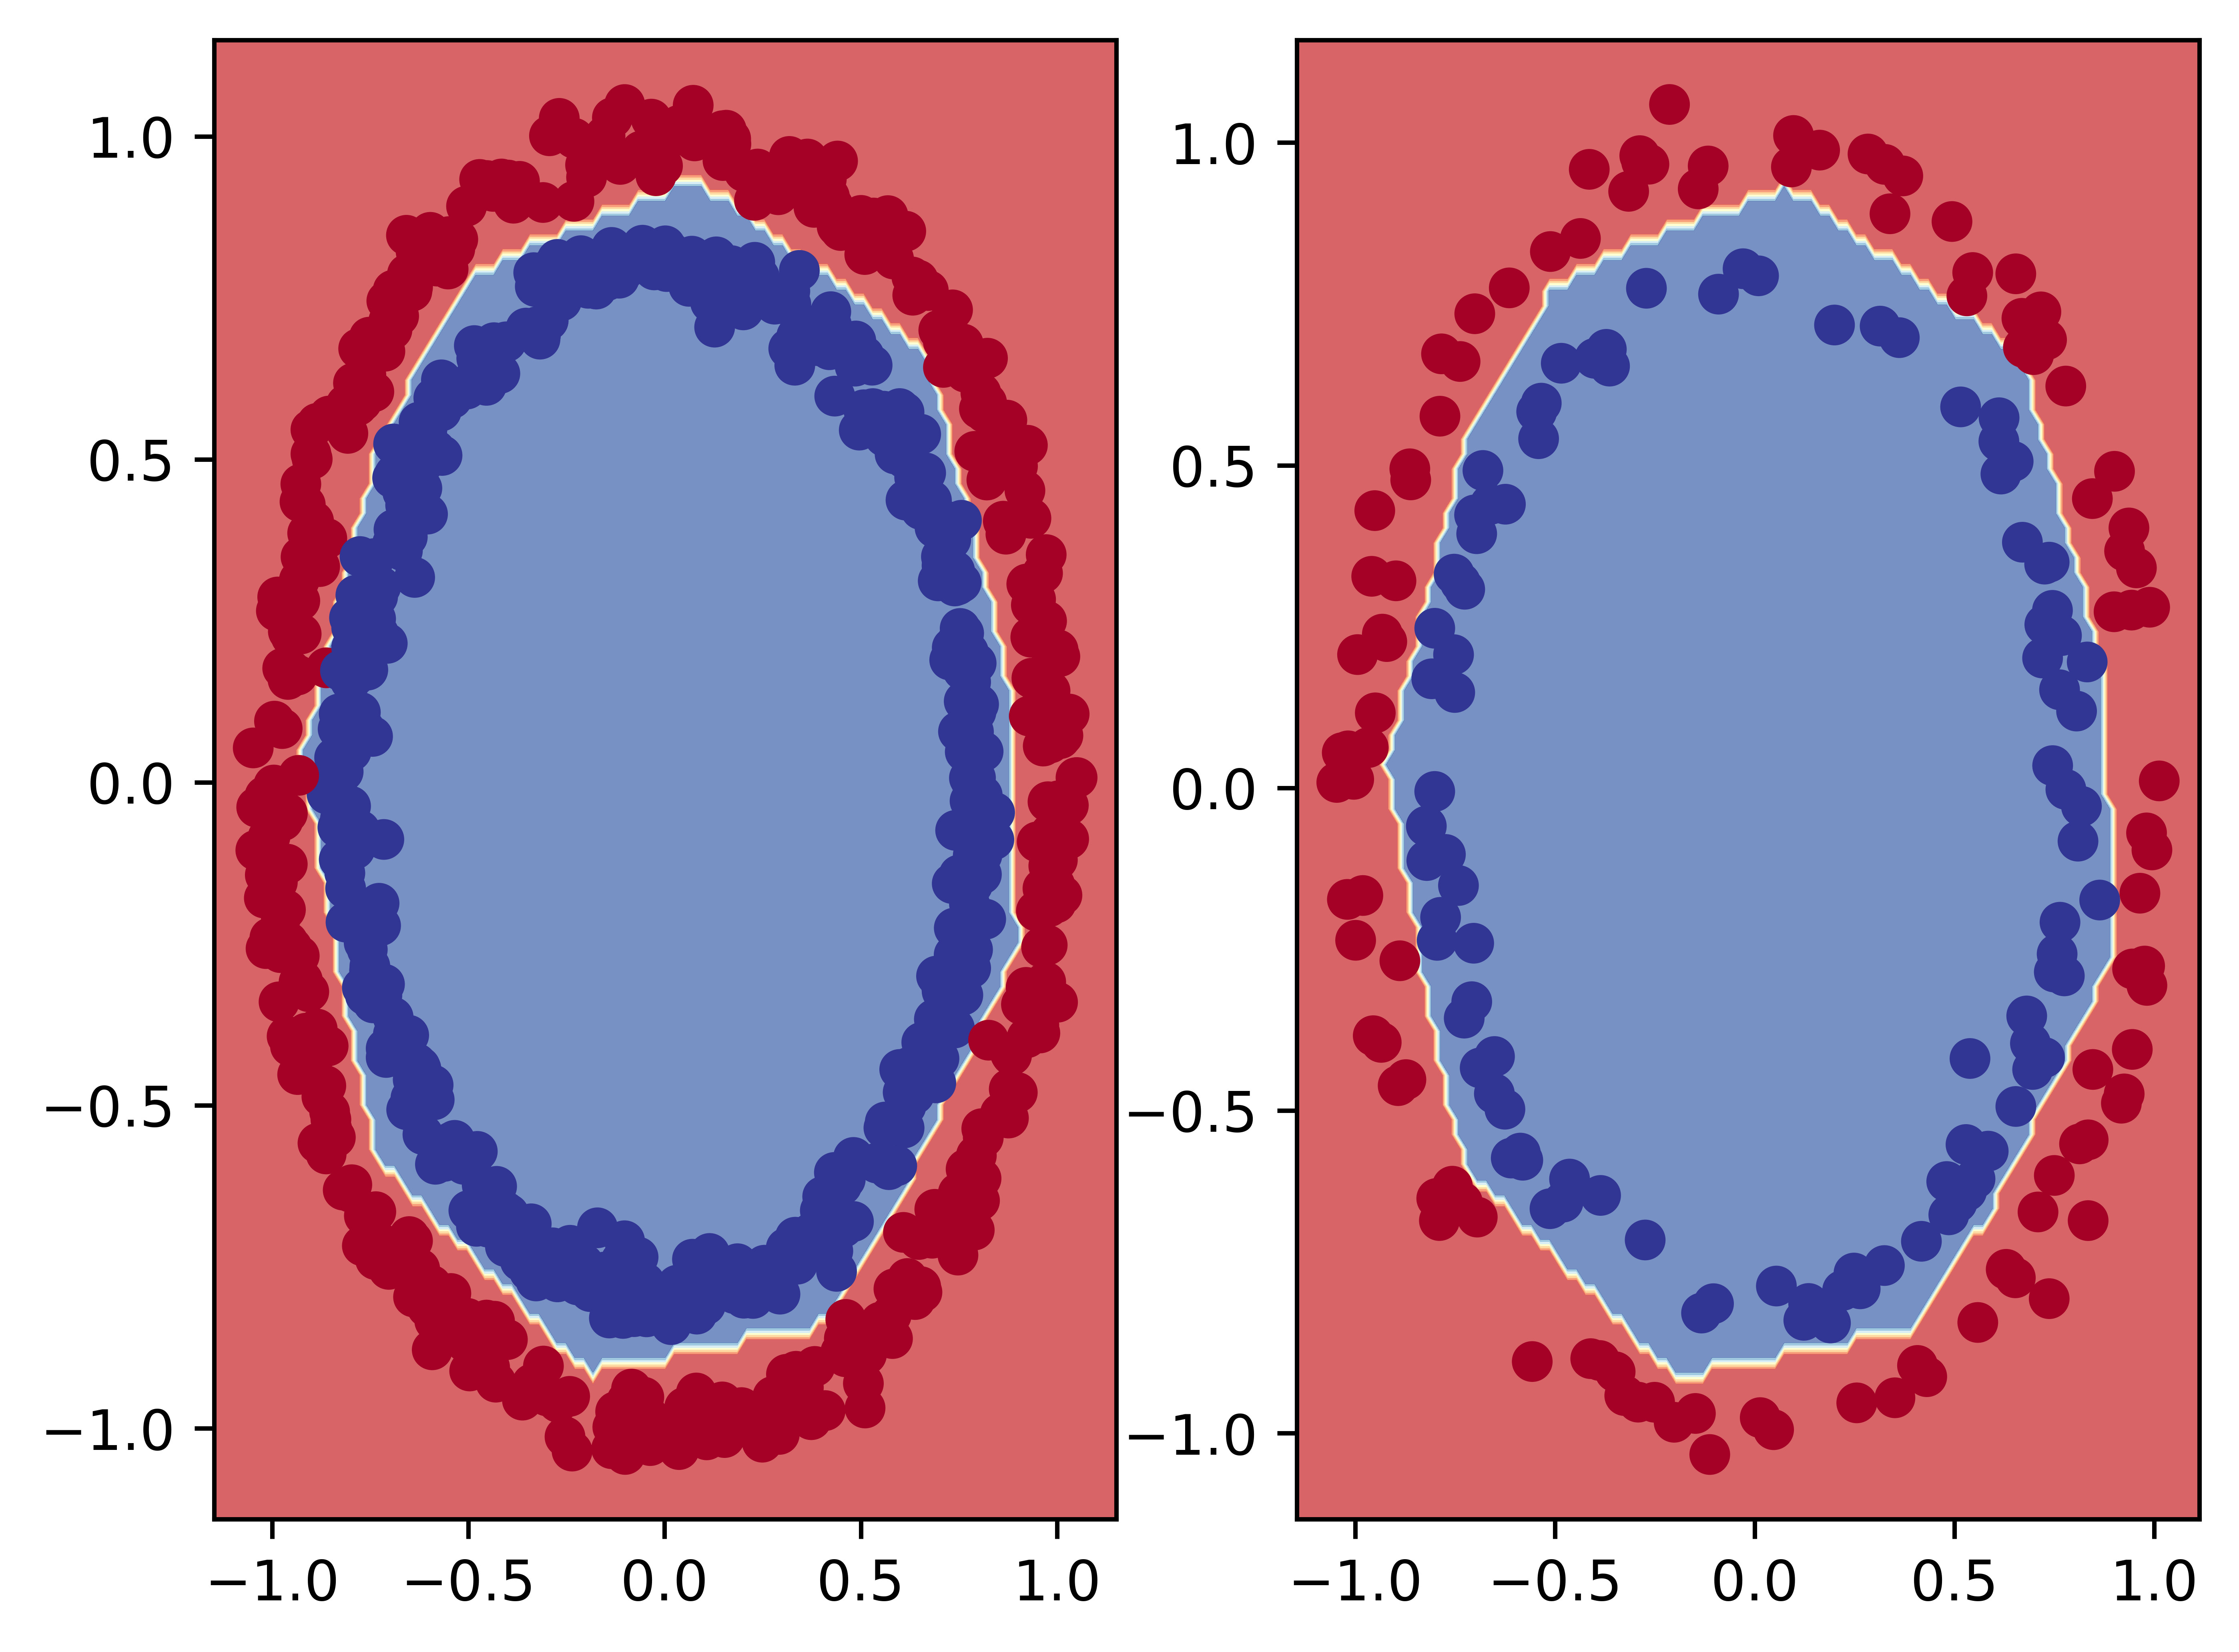

In [37]:
from helper_functions import plot_predictions,plot_decision_boundary
plt.figure(dpi=1000)
plt.subplot(1,2,1)
plot_decision_boundary(model,x_train,y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model,x_test,test_preds)

## Replicating of the non linear function sing raw pytorch functions

* rather than we code them eplicitly we give the tools and let it figure it out to find the best 

In [39]:
## 
a=torch.arange(-10,10,1,dtype=torch.float32)
a.dtype

torch.float32

In [40]:
a

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

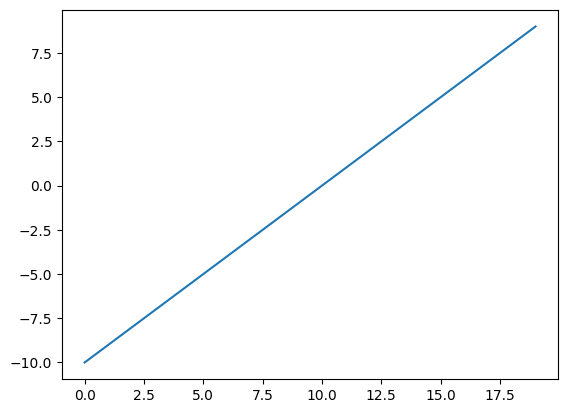

In [41]:
plt.plot(a)

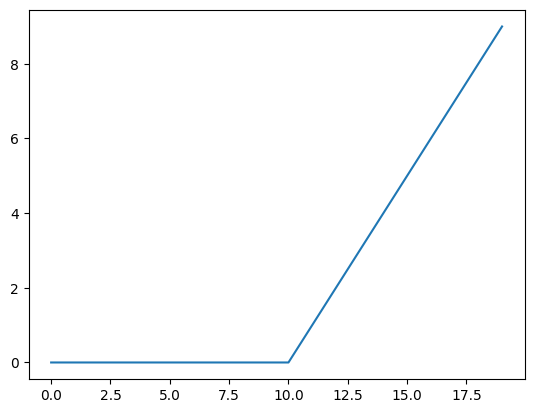

In [42]:
plt.plot(torch.relu(a))

## tha above is the graphical representation of ReLU function

In [43]:
def relu(x:torch.Tensor)->torch.Tensor:
    return torch.maximum(torch.tensor(0),x)
    

In [44]:
relu(a)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

## Although ReLU was not no complex and non-linear it was used to reduce the computational complexity

In [45]:
## ReLU quite simple but powerful

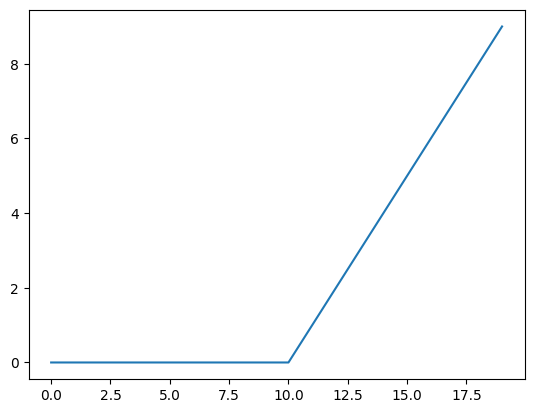

In [46]:
plt.plot(relu(a))

In [47]:
## new do the same for the sigmoid

In [49]:
def sigmoid(x:torch.Tensor)->torch.Tensor:
    return 1/(1+(torch.exp(-x)))

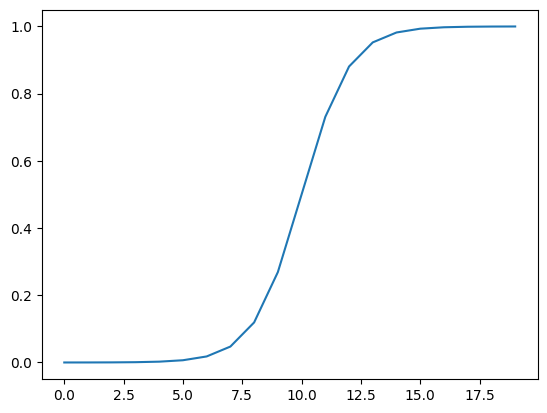

In [50]:
plt.plot(torch.sigmoid(a))

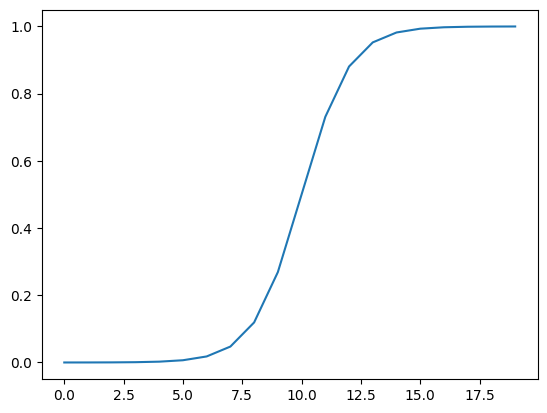

In [51]:
plt.plot(sigmoid(a))

## Multiclass classification
* Binary classification = one thing or another 
* Multi-class classification

In [ ]:
##